In [ ]:
!pip install sympy==1.12


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 21.3 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cpu requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/MLP')


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split

from dataset import APTOSDataset

In [4]:
# import torchvision.transforms.functional as F

# class SquarePad:
#     def __call__(self, image):
#         w, h = image.size
#         max_wh = max(w, h)

#         hp = (max_wh - w) // 2
#         vp = (max_wh - h) // 2

#         padding = (hp, vp, max_wh - w - hp, max_wh - h - vp)

#         return F.pad(image, padding, fill=0)

import torchvision.transforms.functional as TF

class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = max(w, h)
        hp = (max_wh - w) // 2
        vp = (max_wh - h) // 2
        padding = [hp, vp, max_wh - w - hp, max_wh - h - vp]

        # We call the torchvision-specific pad which handles PIL Images perfectly
        return TF.pad(image, padding, fill=0, padding_mode='constant')

print("✅ SquarePad is now PIL-compatible and alias-safe.")

✅ SquarePad is now PIL-compatible and alias-safe.


In [5]:
csv_path = "/content/drive/MyDrive/MLP/aptos_dataset/train.csv"
image_dir = "/content/drive/MyDrive/MLP/aptos_dataset"

df = pd.read_csv(csv_path)


In [6]:
print(df.head())


        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [7]:
import os

missing = []

for img_id in df['id_code']:
    path = os.path.join(image_dir, img_id + ".png")
    if not os.path.exists(path):
        missing.append(img_id)

print("Missing files:", len(missing))
print(missing[:10])

Missing files: 0
[]


In [8]:

df = df[df['id_code'].apply(
    lambda x: os.path.exists(os.path.join(image_dir, x + ".png"))
)].reset_index(drop=True)

print("Filtered dataset size:", df.shape)


Filtered dataset size: (3662, 2)


In [9]:
# Create ordinal thresholds for each label
def make_thresholds(label):
    return [1 if label >= i else 0 for i in range(1, 5)]

df['thresholds'] = df['diagnosis'].apply(make_thresholds)


In [10]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['diagnosis'],
    random_state=78
)

In [11]:
# transform_train = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.RandomRotation(10),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

transform_train = transforms.Compose([
    SquarePad(),
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),

    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
# transform_val = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

transform_val = transforms.Compose([
    SquarePad(),
    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:
train_dataset = APTOSDataset(train_df, image_dir, transform_train)
val_dataset = APTOSDataset(val_df, image_dir, transform_val)

In [14]:
class_counts_tr = train_df['diagnosis'].value_counts().sort_index().values
class_counts_vl = val_df['diagnosis'].value_counts().sort_index().values

print(train_df.shape)
print(val_df.shape)
print(f"Class counts of train set: {class_counts_tr}")
print(f"Class counts of val set: {class_counts_vl}")

(2929, 3)
(733, 3)
Class counts of train set: [1444  296  799  154  236]
Class counts of val set: [361  74 200  39  59]


In [15]:
class_weights = 1. / class_counts_tr
sample_weights = torch.tensor(
    train_df['diagnosis'].map(
        {i: class_weights[i] for i in range(len(class_weights))}
    ).values,
    dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler = sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle = False
)

testing below

In [17]:

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Unique labels in batch:", labels.unique())

Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16, 4])
Unique labels in batch: tensor([0., 1.])


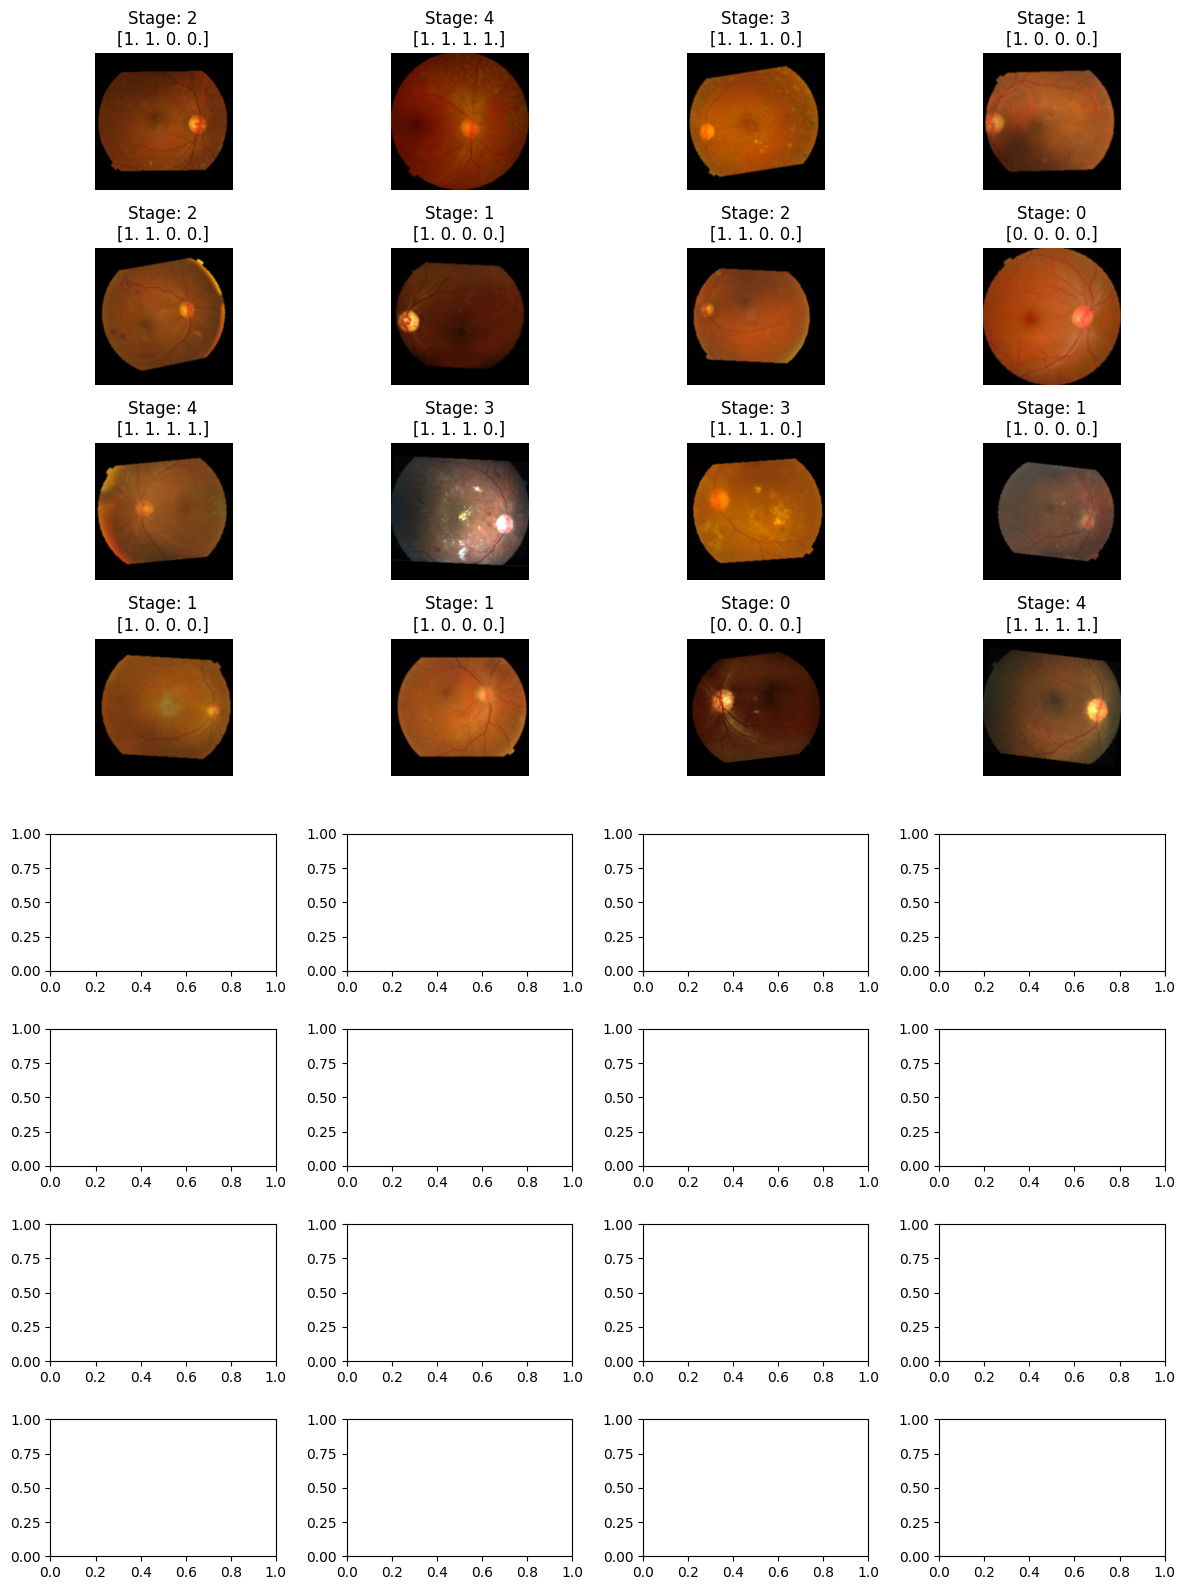

In [18]:
# modified for ordinal
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

figs, axes = plt.subplots(8, 4, figsize=(12, 16))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    # Get ordinal label vector
    threshold_vec = labels[i].cpu().numpy()

    # Convert thresholds to stage (sum of ones)
    stage = int(threshold_vec.sum())

    axes[i].set_title(f"Stage: {stage}\n{threshold_vec}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [19]:
# WeightedRandomSampler samples the minority classes so in one batch, the class counts are approximately equal

images, labels = next(iter(train_loader))
unique, counts = torch.unique(labels, return_counts=True)
print(dict(zip(unique.tolist(), counts.tolist())))

{0.0: 45, 1.0: 19}


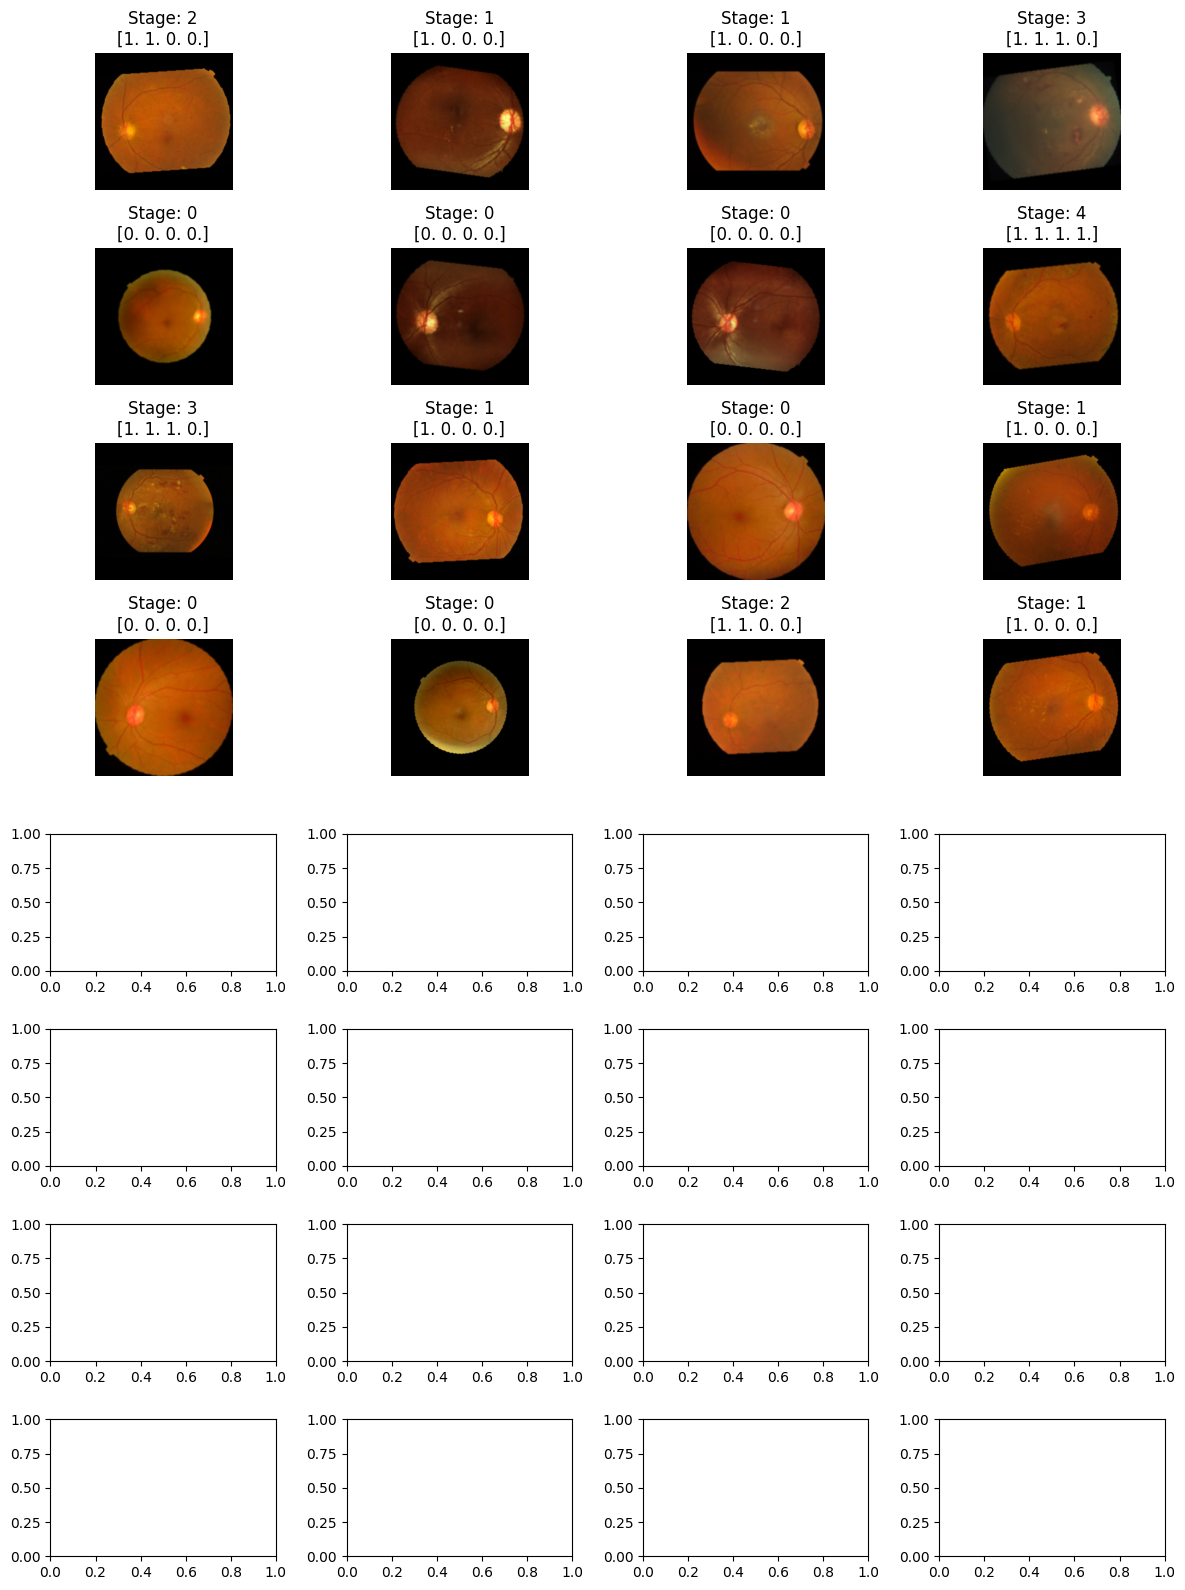

In [20]:
# modified for ordinal
# visualizing one whole batch, transformations are visible in the images

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

figs, axes = plt.subplots(8, 4, figsize=(12, 16))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    # Get ordinal label vector
    threshold_vec = labels[i].cpu().numpy()

    # Convert thresholds to stage (sum of ones)
    stage = int(threshold_vec.sum())

    axes[i].set_title(f"Stage: {stage}\n{threshold_vec}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


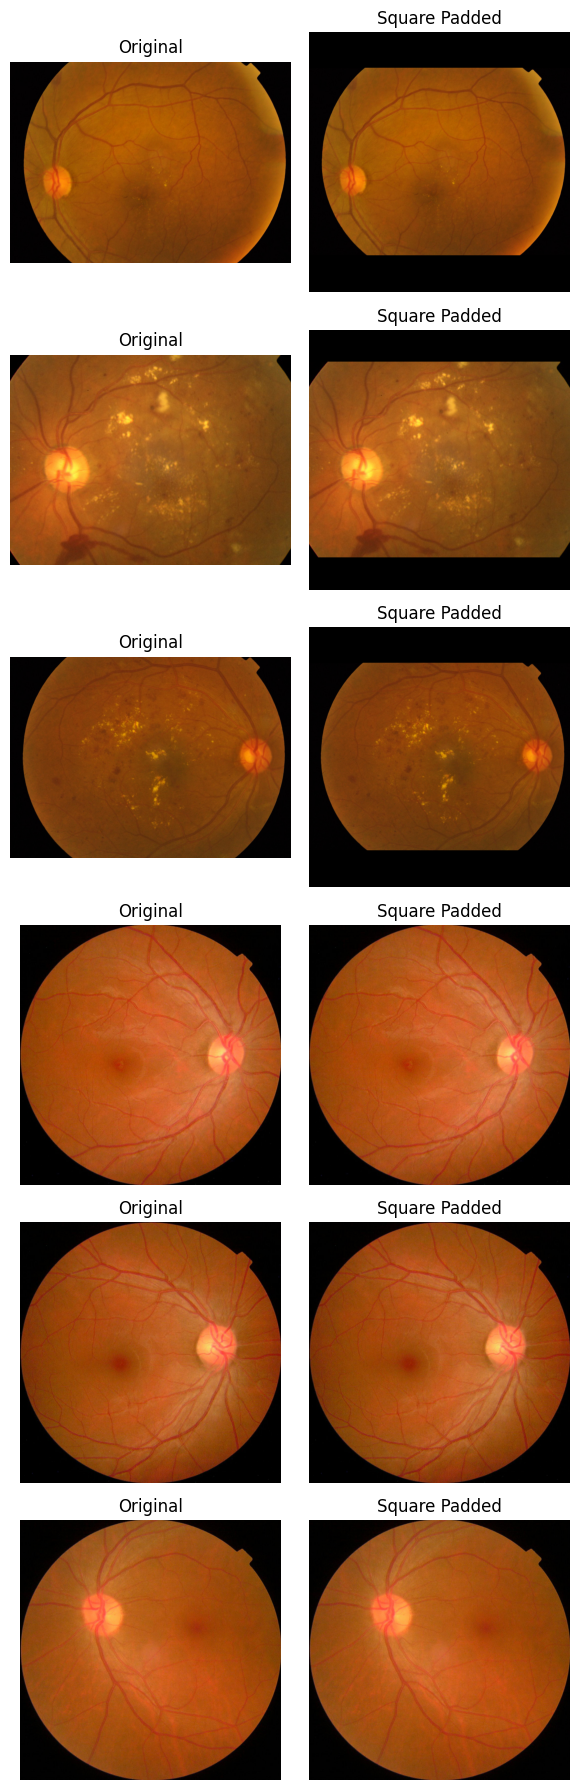

In [21]:
import matplotlib.pyplot as plt
from PIL import Image
import os

square_pad = SquarePad()

sample_images = df['id_code'].sample(6).values

fig, axes = plt.subplots(6, 2, figsize=(6, 18))

for i, img_id in enumerate(sample_images):

    path = os.path.join(image_dir, img_id + ".png")
    img = Image.open(path).convert("RGB")

    padded = square_pad(img)

    axes[i,0].imshow(img)
    axes[i,0].set_title("Original")
    axes[i,0].axis("off")

    axes[i,1].imshow(padded)
    axes[i,1].set_title("Square Padded")
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()

**RESNET-50**

**Imports for Training & Evaluation**

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


**Convert DR Labels → Ordinal Thresholds**

In [23]:
# Convert DR stage → ordinal thresholds
# Example: stage 2 -> [1,1,0,0]

def dr_to_thresholds(label):
    return [int(label >= t) for t in range(1,5)]

train_df['thresholds'] = train_df['diagnosis'].apply(dr_to_thresholds)
val_df['thresholds'] = val_df['diagnosis'].apply(dr_to_thresholds)

print(train_df[['diagnosis','thresholds']].head())

      diagnosis    thresholds
2976          0  [0, 0, 0, 0]
2017          1  [1, 0, 0, 0]
822           4  [1, 1, 1, 1]
1973          2  [1, 1, 0, 0]
3201          0  [0, 0, 0, 0]


**Build ResNet50 Ordinal Model**

In [24]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)   # 4 thresholds

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

**Stage-Weighted Loss (for class imbalance)**

In [25]:
# Compute stage weights from training data
stage_counts = train_df['diagnosis'].value_counts().sort_index()

stage_weights = 1.0 / stage_counts
stage_weights = stage_weights / stage_weights.sum()

print("Stage weights:")
print(stage_weights)

# Convert stage weights → threshold weights
threshold_weights = torch.tensor([
    stage_weights[1:].sum(),  # DR ≥1
    stage_weights[2:].sum(),  # DR ≥2
    stage_weights[3:].sum(),  # DR ≥3
    stage_weights[4]          # DR ≥4
]).float().to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=threshold_weights)

Stage weights:
diagnosis
0    0.043139
1    0.210448
2    0.077963
3    0.404498
4    0.263952
Name: count, dtype: float64


**Optimizer & Scheduler**

In [26]:
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print("Optimizer and scheduler ready.")

Optimizer and scheduler ready.


**Sanity Check Batch**

In [27]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)  # [batch,3,224,224]
print("Labels:", labels.shape)  # [batch,4]
print(labels[0])

Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16, 4])
tensor([0., 0., 0., 0.])


**Training Loop**

In [29]:
# Path to save checkpoints in Drive
checkpoint_path = "/content/drive/MyDrive/MLP/dr_resnet50_checkpoint.pth"
best_model_path = "/content/drive/MyDrive/MLP/dr_resnet50_best_model.pth"

num_epochs = 5
start_epoch = 0
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(start_epoch, num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):

        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # -------------------
    # Validation
    # -------------------

    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device).float()

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {epoch_train_loss:.4f}")
    print(f"Val Loss: {epoch_val_loss:.4f}")

    scheduler.step(epoch_val_loss)

    # -------------------
    # Save checkpoint
    # -------------------

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': epoch_train_loss,
        'val_loss': epoch_val_loss
    }, checkpoint_path)

    print(f"Checkpoint saved to Drive at epoch {epoch+1}")

    # -------------------
    # Save best model
    # -------------------

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss

        torch.save(model.state_dict(), best_model_path)

        print("✅ Best model updated and saved to Drive")

Epoch 1/5:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 1
Train Loss: 0.1685
Val Loss: 0.1222
Checkpoint saved to Drive at epoch 1
✅ Best model updated and saved to Drive


Epoch 2/5:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 2
Train Loss: 0.1476
Val Loss: 0.1262
Checkpoint saved to Drive at epoch 2


Epoch 3/5:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 3
Train Loss: 0.1215
Val Loss: 0.1278
Checkpoint saved to Drive at epoch 3


Epoch 4/5:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 4
Train Loss: 0.1144
Val Loss: 0.1037
Checkpoint saved to Drive at epoch 4
✅ Best model updated and saved to Drive


Epoch 5/5:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 5
Train Loss: 0.1006
Val Loss: 0.1245
Checkpoint saved to Drive at epoch 5


**Load Checkpoint (Resume Training Later)**

In [28]:
# If Colab disconnects, run this before training.
# Then run the training cell again.

checkpoint_path = "/content/drive/MyDrive/MLP/dr_resnet50_checkpoint.pth"

checkpoint = torch.load(checkpoint_path)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch'] + 1

print("Checkpoint loaded.")
print("Resuming from epoch:", start_epoch)

Checkpoint loaded.
Resuming from epoch: 1


**loss plot**

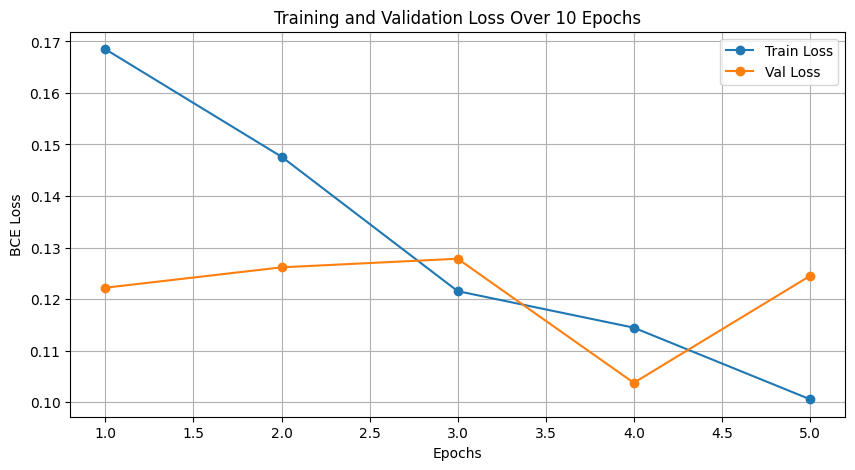

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Val Loss', marker='o')
plt.title('Training and Validation Loss Over 10 Epochs')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)
plt.show()

**Ordinal Prediction Decoding**

In [31]:
def decode_ordinal_predictions(logits):

    probs = torch.sigmoid(logits)

    preds = (probs > 0.5).int()

    stage_preds = preds.sum(dim=1)

    return stage_preds

**Run Validation Predictions**

In [32]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        logits = model(images)

        preds = decode_ordinal_predictions(logits).cpu().numpy()

        true = labels.numpy().sum(axis=1)

        all_preds.extend(preds)
        all_labels.extend(true)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

**Overall Metrics**

In [33]:
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

print("Overall Metrics")
print("----------------")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"QWK      : {qwk:.4f}")

Overall Metrics
----------------
Accuracy : 0.7722
Precision: 0.6539
Recall   : 0.6584
F1 Score : 0.6168
QWK      : 0.8890


**Stage-Wise Accuracy**

In [34]:
cm = confusion_matrix(all_labels, all_preds)

print("Stage-wise Accuracy")

for stage in range(5):

    correct = cm[stage, stage]
    total = cm[stage].sum()

    acc = correct / total if total > 0 else 0

    print(f"Stage {stage}: {acc:.4f} ({correct}/{total})")

Stage-wise Accuracy
Stage 0: 0.9834 (355/361)
Stage 1: 0.8108 (60/74)
Stage 2: 0.5350 (107/200)
Stage 3: 0.6410 (25/39)
Stage 4: 0.3220 (19/59)


**Confusion Matrix Visualization**

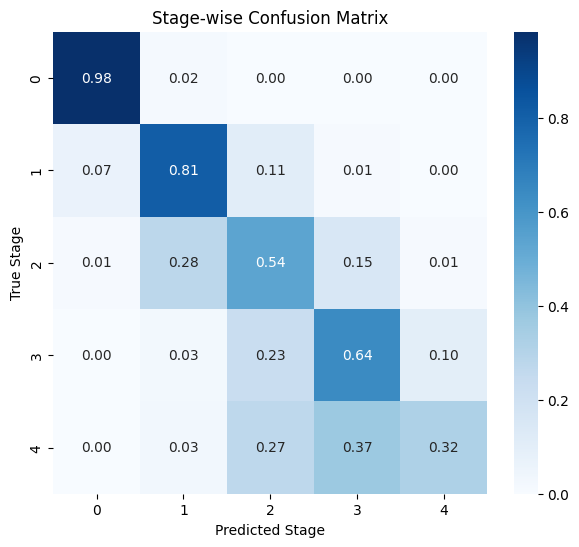

In [35]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_normalized,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    xticklabels=["0","1","2","3","4"],
    yticklabels=["0","1","2","3","4"]
)

plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.title("Stage-wise Confusion Matrix")

plt.show()

**Ordinal Error Distance Plot**

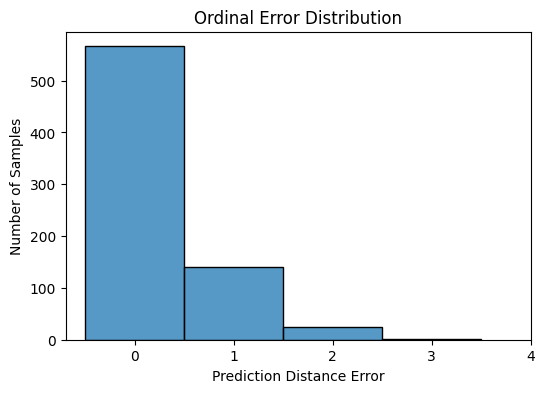

In [36]:
errors = np.abs(all_labels - all_preds)

plt.figure(figsize=(6,4))

sns.histplot(errors, bins=np.arange(0,6)-0.5, discrete=True)

plt.xlabel("Prediction Distance Error")
plt.ylabel("Number of Samples")
plt.title("Ordinal Error Distribution")

plt.xticks(range(5))
plt.show()

Idrid

In [37]:
best_model_path = "/content/drive/MyDrive/MLP/dr_resnet50_best_model.pth"

model.load_state_dict(torch.load(best_model_path))

model.eval()

print("Best trained model loaded for cross-dataset testing.")

Best trained model loaded for cross-dataset testing.


In [38]:
# idrid_train_csv = "/content/drive/MyDrive/MLP/idrid_dataset/ground_truth/training_labels.csv"
# idrid_test_csv = "/content/drive/MyDrive/MLP/idrid_dataset/ground_truth/testing_labels.csv"

# idrid_train_images = "/content/drive/MyDrive/MLP/idrid_dataset/original_images/training_images"
# idrid_test_images = "/content/drive/MyDrive/MLP/idrid_dataset/original_images/testing_images"

In [39]:
# Define Paths
idrid_train_csv = "/content/drive/MyDrive/MLP/idrid_dataset/ground_truth/training_labels.csv"
idrid_test_csv = "/content/drive/MyDrive/MLP/idrid_dataset/ground_truth/testing_labels.csv"

idrid_train_images = "/content/drive/MyDrive/MLP/idrid_dataset/original_images/training_images"
idrid_test_images = "/content/drive/MyDrive/MLP/idrid_dataset/original_images/testing_images"

# Load Dataframes
idrid_train_df = pd.read_csv(idrid_train_csv)
idrid_test_df = pd.read_csv(idrid_test_csv)

# --- THE CLEANING FIX ---
# 1. Strip whitespace from column names
idrid_test_df.columns = idrid_test_df.columns.str.strip()
idrid_train_df.columns = idrid_train_df.columns.str.strip()

# 2. Keep only the columns we need
idrid_test_df = idrid_test_df[['Image name', 'Retinopathy grade']]
idrid_train_df = idrid_train_df[['Image name', 'Retinopathy grade']]

# 3. Rename to match APTOS format ('id_code' and 'diagnosis')
idrid_test_df = idrid_test_df.rename(columns={'Image name': 'id_code', 'Retinopathy grade': 'diagnosis'})
idrid_train_df = idrid_train_df.rename(columns={'Image name': 'id_code', 'Retinopathy grade': 'diagnosis'})

# 4. Standardize id_code (Keep original casing for IDRiD)
idrid_test_df['id_code'] = idrid_test_df['id_code'].astype(str).str.strip()
idrid_train_df['id_code'] = idrid_train_df['id_code'].astype(str).str.strip()

# 5. Create Ordinal Thresholds
idrid_test_df["thresholds"] = idrid_test_df["diagnosis"].apply(make_thresholds)
idrid_train_df["thresholds"] = idrid_train_df["diagnosis"].apply(make_thresholds)

print("IDRiD Test Set Cleaned (Preserving Case):")
print(idrid_test_df.head())

IDRiD Test Set Cleaned (Preserving Case):
     id_code  diagnosis    thresholds
0  IDRiD_001          4  [1, 1, 1, 1]
1  IDRiD_002          4  [1, 1, 1, 1]
2  IDRiD_003          4  [1, 1, 1, 1]
3  IDRiD_004          4  [1, 1, 1, 1]
4  IDRiD_005          4  [1, 1, 1, 1]


In [40]:
# Reuse your existing transform_val (SquarePad + Resize + Normalize)
idrid_test_dataset = APTOSDataset(
    idrid_test_df,
    idrid_test_images,
    transform_val
)

idrid_loader = DataLoader(
    idrid_test_dataset,
    batch_size=32,
    shuffle=False
)

print(f"IDRiD DataLoader ready with {len(idrid_test_dataset)} images.")

IDRiD DataLoader ready with 103 images.


In [41]:
# import os
# # Look at the first 5 files in your IDRiD test folder
# path = "/content/drive/MyDrive/MLP/idrid_dataset/original_images/testing_images"
# files = os.listdir(path)
# print("Files found in folder:", files[:5])

In [42]:
best_model_path = "/content/drive/MyDrive/MLP/dr_resnet50_best_model.pth"
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

idrid_preds = []
idrid_labels = []

with torch.no_grad():
    for images, labels in tqdm(idrid_loader, desc="Testing IDRiD"):
        images = images.to(device)

        logits = model(images)

        # Using your existing decoding function
        preds = decode_ordinal_predictions(logits).cpu().numpy()

        # Convert ordinal labels back to single integer (sum of 1s)
        true = labels.numpy().sum(axis=1)

        idrid_preds.extend(preds)
        idrid_labels.extend(true)

idrid_preds = np.array(idrid_preds)
idrid_labels = np.array(idrid_labels)

Testing IDRiD:   0%|          | 0/4 [00:00<?, ?it/s]

In [43]:
import pandas as pd

# 1. Gather APTOS Stage-wise Sensitivity/Accuracy
# (Assuming 'all_labels' and 'all_preds' are your APTOS validation results)
cm_aptos = confusion_matrix(all_labels, all_preds)
aptos_stats = []
for stage in range(5):
    val = (cm_aptos[stage, stage] / cm_aptos[stage].sum()) if cm_aptos[stage].sum() > 0 else 0
    aptos_stats.append(val)

# 2. Gather IDRiD Stage-wise Sensitivity/Accuracy
# (Assuming 'idrid_labels' and 'idrid_preds' are your IDRiD results)
cm_idrid = confusion_matrix(idrid_labels, idrid_preds)
idrid_stats = []
for stage in range(5):
    val = (cm_idrid[stage, stage] / cm_idrid[stage].sum()) if cm_idrid[stage].sum() > 0 else 0
    idrid_stats.append(val)

# 3. Combine into a Comparison DataFrame
comparison_df = pd.DataFrame({
    'DR Stage': ['0 (Normal)', '1 (Mild)', '2 (Moderate)', '3 (Severe)', '4 (Proliferative)'],
    'APTOS Sensitivity': aptos_stats,
    'IDRiD Sensitivity': idrid_stats
})

# 4. Calculate the "Drop" due to Domain Shift
comparison_df['Performance Drop (%)'] = (comparison_df['APTOS Sensitivity'] - comparison_df['IDRiD Sensitivity']) * 100

# Format for clear reading
pd.options.display.float_format = '{:.4f}'.format

print("="*60)
print("FINAL DISSERTATION COMPARISON TABLE: APTOS vs. IDRiD")
print("="*60)
print(comparison_df.to_string(index=False))
print("-" * 60)

# Optional: Print Overall QWK Comparison
aptos_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
idrid_qwk = cohen_kappa_score(idrid_labels, idrid_preds, weights='quadratic')

print(f"\nOVERALL MODEL ROBUSTNESS (QWK)")
print(f"APTOS (In-Domain): {aptos_qwk:.4f}")
print(f"IDRiD (Cross-Domain): {idrid_qwk:.4f}")
print(f"QWK Retention: {(idrid_qwk/aptos_qwk)*100:.2f}%")

# 3. Simple Comparison Note
# (You can manually check these against your earlier APTOS results)
print("\nNote: Compare these to your APTOS validation metrics to discuss 'Domain Shift' in your thesis.")

FINAL DISSERTATION COMPARISON TABLE: APTOS vs. IDRiD
         DR Stage  APTOS Sensitivity  IDRiD Sensitivity  Performance Drop (%)
       0 (Normal)             0.9834             0.0000               98.3380
         1 (Mild)             0.8108             0.6000               21.0811
     2 (Moderate)             0.5350             0.5938               -5.8750
       3 (Severe)             0.6410             0.5263               11.4710
4 (Proliferative)             0.3220             0.0000               32.2034
------------------------------------------------------------

OVERALL MODEL ROBUSTNESS (QWK)
APTOS (In-Domain): 0.8890
IDRiD (Cross-Domain): 0.5088
QWK Retention: 57.23%

Note: Compare these to your APTOS validation metrics to discuss 'Domain Shift' in your thesis.


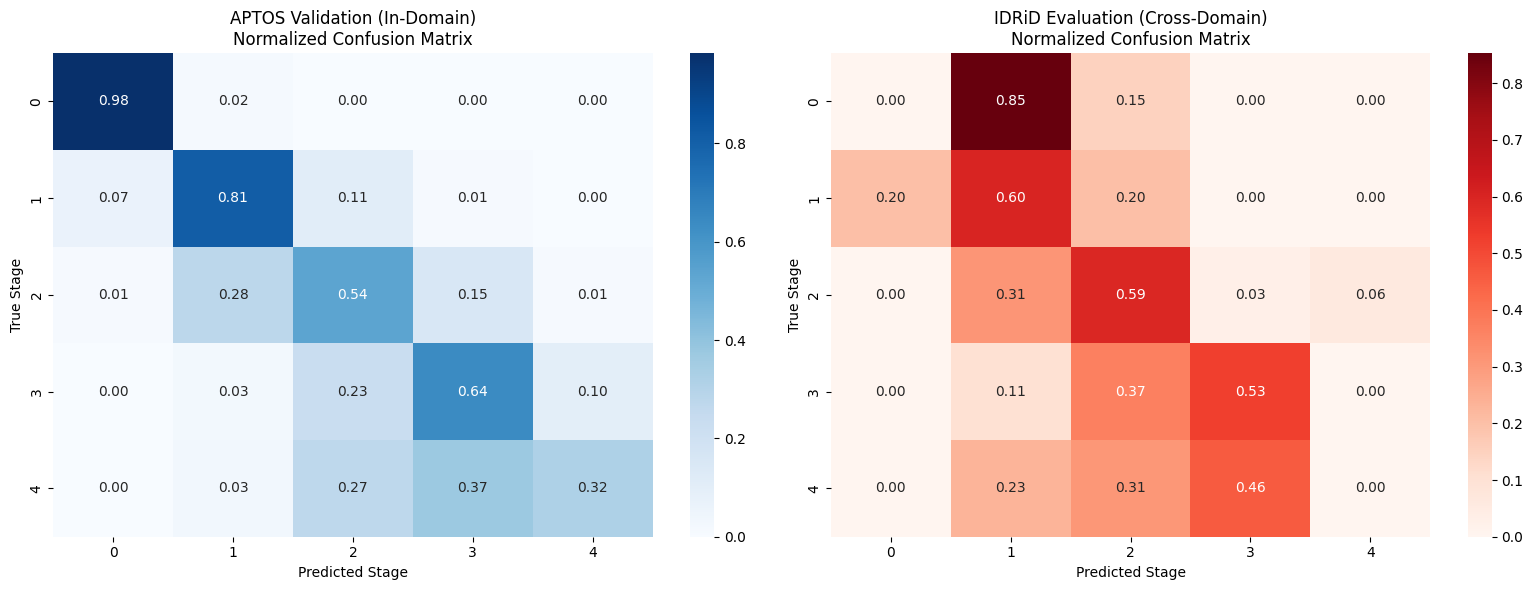

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_dual_confusion_matrix(all_labels_aptos, all_preds_aptos, all_labels_idrid, all_preds_idrid):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. APTOS (In-Domain)
    cm_aptos = confusion_matrix(all_labels_aptos, all_preds_aptos)
    cm_aptos_norm = cm_aptos.astype('float') / cm_aptos.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_aptos_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
                xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    axes[0].set_title('APTOS Validation (In-Domain)\nNormalized Confusion Matrix')
    axes[0].set_xlabel('Predicted Stage')
    axes[0].set_ylabel('True Stage')

    # 2. IDRiD (Cross-Domain)
    cm_idrid = confusion_matrix(all_labels_idrid, all_preds_idrid)
    cm_idrid_norm = cm_idrid.astype('float') / cm_idrid.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_idrid_norm, annot=True, fmt='.2f', cmap='Reds', ax=axes[1],
                xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    axes[1].set_title('IDRiD Evaluation (Cross-Domain)\nNormalized Confusion Matrix')
    axes[1].set_xlabel('Predicted Stage')
    axes[1].set_ylabel('True Stage')

    plt.tight_layout()
    plt.show()

# Run the visualization
# Note: Ensure 'all_labels' and 'all_preds' from your APTOS run are still in memory
plot_dual_confusion_matrix(all_labels, all_preds, idrid_labels, idrid_preds)

**GRAD-CAM implementation**

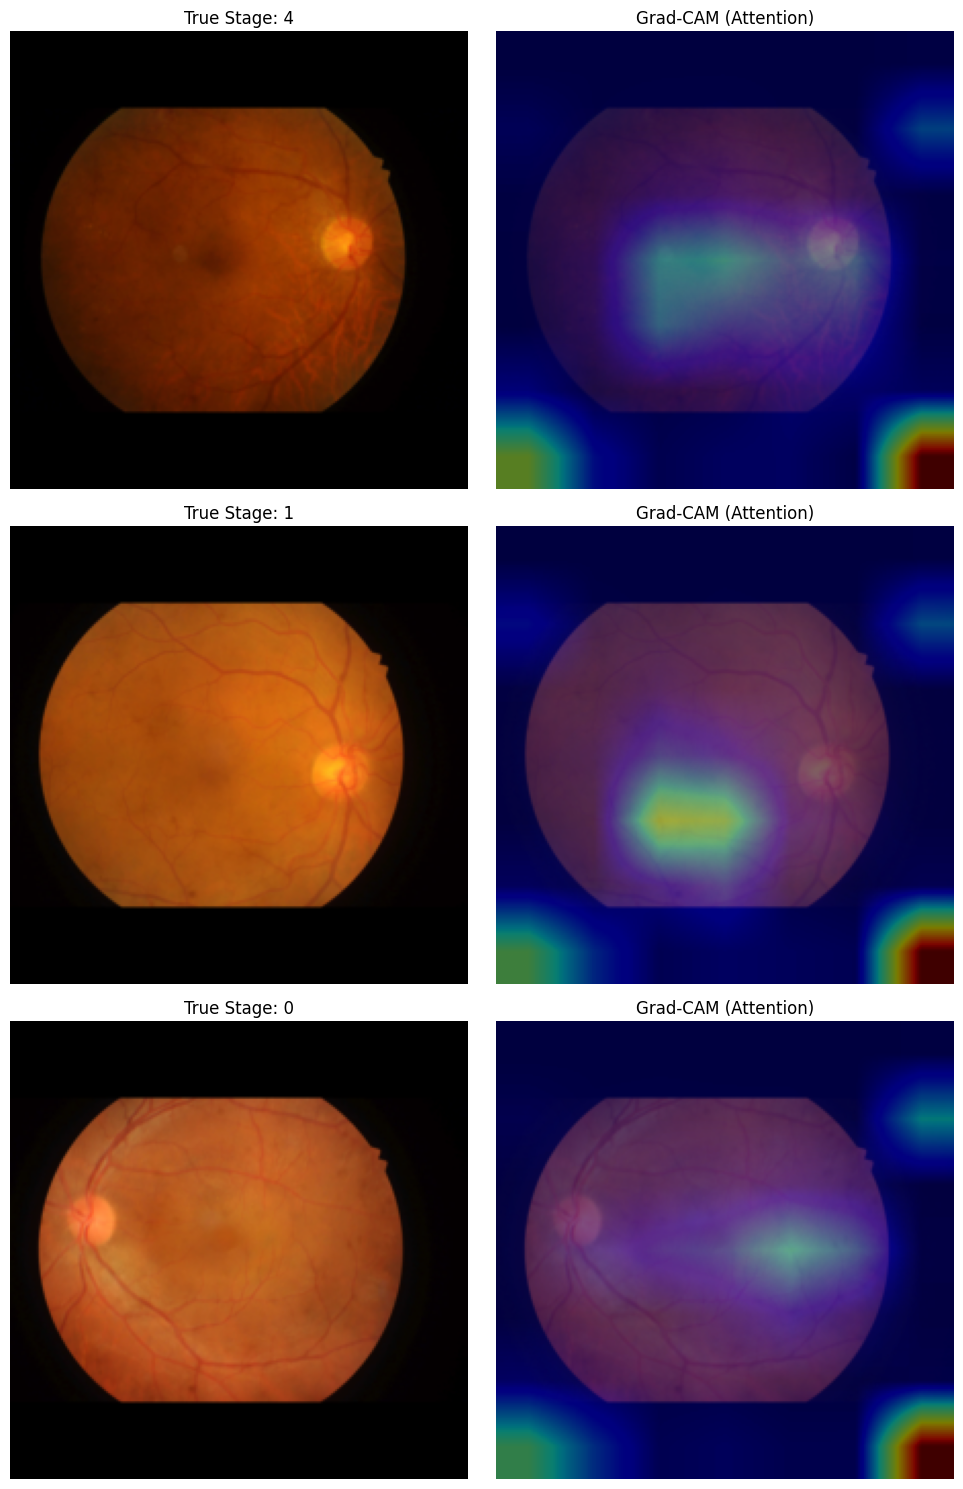

In [45]:
import torch.nn.functional as F
import cv2

def generate_gradcam(model, input_batch, target_layer):
    """Generates Grad-CAM heatmap for the first image in a batch."""
    model.eval()

    # 1. Hook to get gradients and activations
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])
    def forward_hook(module, input, output):
        activations.append(output)

    # Attach hooks to the target layer (last conv layer)
    handle_b = target_layer.register_full_backward_hook(backward_hook)
    handle_f = target_layer.register_forward_hook(forward_hook)

    # 2. Forward pass
    logits = model(input_batch)

    # Target the highest predicted class
    score = logits[:, logits.argmax(dim=1)].sum()

    # 3. Backward pass
    model.zero_grad()
    score.backward()

    # 4. Process Grad-CAM
    grads = gradients[0].cpu().data.numpy()
    f_maps = activations[0].cpu().data.numpy()

    # Weights = Global Average Pooling of gradients
    weights = np.mean(grads, axis=(2, 3))[0]
    cam = np.zeros(f_maps.shape[2:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * f_maps[0, i, :, :]

    cam = np.maximum(cam, 0) # ReLU
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8) # Normalize

    # Clean up hooks
    handle_b.remove()
    handle_f.remove()

    return cam

def plot_gradcam_results(model, dataset, indices, device):
    fig, axes = plt.subplots(len(indices), 2, figsize=(10, 5 * len(indices)))

    for i, idx in enumerate(indices):
        img_tensor, label_vec = dataset[idx]
        input_batch = img_tensor.unsqueeze(0).to(device)

        # Target layer for ResNet-50 is usually layer4
        heatmap = generate_gradcam(model, input_batch, model.layer4)

        # Convert tensor back to image for display
        img = img_tensor.cpu().numpy().transpose(1, 2, 0)
        img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406] # Un-normalize
        img = np.clip(img, 0, 1)

        # Plot Original
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"True Stage: {int(label_vec.sum())}")
        axes[i, 0].axis('off')

        # Plot Heatmap Overlay
        axes[i, 1].imshow(img)
        axes[i, 1].imshow(heatmap, cmap='jet', alpha=0.5) # Overlay
        axes[i, 1].set_title("Grad-CAM (Attention)")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize 3 random samples from IDRiD
sample_indices = np.random.choice(len(idrid_test_dataset), 3, replace=False)
plot_gradcam_results(model, idrid_test_dataset, sample_indices, device)

In [46]:
import pandas as pd
from sklearn.metrics import confusion_matrix, cohen_kappa_score

def get_full_metrics(labels, preds):
    cm = confusion_matrix(labels, preds, labels=[0, 1, 2, 3, 4])
    stats = []
    for stage in range(5):
        tp = cm[stage, stage]
        actual_total = cm[stage, :].sum()
        predicted_total = cm[:, stage].sum()

        # Row-based: Sensitivity and Stage-wise Accuracy
        val = (tp / actual_total) if actual_total > 0 else 0
        # Column-based: Precision
        prec = (tp / predicted_total) if predicted_total > 0 else 0

        stats.append({
            "Acc": val,
            "Sens": val,
            "Prec": prec
        })
    return stats

# 1. Extract metrics
aptos_m = get_full_metrics(all_labels, all_preds)
idrid_m = get_full_metrics(idrid_labels, idrid_preds)

# 2. Build organized comparison
comparison_data = []
stages = ['0 (Normal)', '1 (Mild)', '2 (Moderate)', '3 (Severe)', '4 (Prolif)']

for i in range(5):
    comparison_data.append({
        'DR Stage': stages[i],
        # APTOS Section
        'APTOS Acc': aptos_m[i]['Acc'],
        'APTOS Sens': aptos_m[i]['Sens'],
        'APTOS Prec': aptos_m[i]['Prec'],
        # IDRiD Section
        'IDRiD Acc': idrid_m[i]['Acc'],
        'IDRiD Sens': idrid_m[i]['Sens'],
        'IDRiD Prec': idrid_m[i]['Prec']
    })

master_df = pd.DataFrame(comparison_data)

# 3. Overall Statistics
aptos_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
idrid_qwk = cohen_kappa_score(idrid_labels, idrid_preds, weights='quadratic')

print("="*115)
print(f"{'':<15} | {'--- APTOS (In-Domain) ---':^30} | {'--- IDRiD (Cross-Domain) ---':^30}")
print("="*115)
print(master_df.to_string(index=False, float_format=lambda x: "{:.4f}".format(x) if isinstance(x, float) else x))
print("-" * 115)
print(f"OVERALL QWK | APTOS: {aptos_qwk:.4f} | IDRiD: {idrid_qwk:.4f} | Retention: {(idrid_qwk/aptos_qwk)*100:.2f}%")
print("="*115)

                |   --- APTOS (In-Domain) ---    |  --- IDRiD (Cross-Domain) --- 
    DR Stage  APTOS Acc  APTOS Sens  APTOS Prec  IDRiD Acc  IDRiD Sens  IDRiD Prec
  0 (Normal)     0.9834      0.9834      0.9780     0.0000      0.0000      0.0000
    1 (Mild)     0.8108      0.8108      0.4800     0.6000      0.6000      0.0638
2 (Moderate)     0.5350      0.5350      0.7643     0.5938      0.5938      0.5278
  3 (Severe)     0.6410      0.6410      0.3165     0.5263      0.5263      0.5882
  4 (Prolif)     0.3220      0.3220      0.7308     0.0000      0.0000      0.0000
-------------------------------------------------------------------------------------------------------------------
OVERALL QWK | APTOS: 0.8890 | IDRiD: 0.5088 | Retention: 57.23%
